# Working with HAML: Converting and Processing HLA Antibody Data

**Demo scripts for the HAML 1.0 specification**

This notebook walks through three fundamental operations with HLA Antibody Markup Language (HAML):

1. **Convert** a laboratory CSV export into standardized HAML XML
2. **Analyze** the HAML file by applying an MFI threshold to classify beads
3. **Virtual Crossmatch** using HAML antibody data and donor HLA typing

Each section is self-contained and can be adapted for your own data.

---

## What is HAML?

HLA single antigen bead (SAB) assays are the standard technology for identifying HLA antibodies in transplant patients. Every transplant center in the US uses them. But the raw data, mean fluorescence intensity (MFI) values for each bead, is exported in vendor-specific CSV formats that differ between One Lambda (Thermo Fisher), Werfen (Immucor), and institutional laboratory information systems.

**HAML** (HLA Antibody Markup Language) is an XML-based standard that provides a single, vendor-neutral format for SAB assay results. It captures:
- Raw MFI values for each bead
- Bead metadata (HLA specificity, bead ID, control beads)
- Assay kit information (manufacturer, lot, catalog number)
- Adjusted MFI calculations and interpretation results
- Patient and sample identifiers

HAML was developed by the [IHIW](https://www.ihiw.org/) Clinical Histocompatibility Laboratory Informatics Working Group and is designed for interoperability between laboratories, analysis software, and clinical decision support tools.

**Schema version:** This notebook targets the HAML 0.6.1 draft schema, which will become HAML 1.0 upon publication.

In [17]:
# Setup: find the repository root and add it to path
import sys
from pathlib import Path

current_path = Path.cwd().resolve()
REPO_ROOT = current_path if (current_path / "scripts").exists() else current_path.parent
sys.path.insert(0, str(REPO_ROOT))

# Verify paths
print(f"Repository root: {REPO_ROOT}")
print(f"Schema: {(REPO_ROOT / 'schema' / 'haml__version_0_6_1.xsd').exists()}")
print(f"Sample data: {(REPO_ROOT / 'data' / 'sample_sab_class1.csv').exists()}")

Repository root: /Users/vmwm/haml-demo
Schema: True
Sample data: True


---

## Part 1: Converting SAB Data to HAML

The most common starting point is a CSV export from laboratory analysis software. Here we convert a One Lambda HLA Fusion export into HAML XML.

### Input: One Lambda Fusion CSV

The standard export has one row per bead with columns for sample ID, bead ID, HLA specificity, raw MFI, and bead count. Beads 1 and 2 are negative and positive controls (no specificity assigned).

In [18]:
import pandas as pd

# Load and preview the input CSV
csv_path = REPO_ROOT / "data" / "sample_sab_class1.csv"
df_input = pd.read_csv(csv_path)

print(f"Input: {csv_path.name}")
print(f"Beads: {len(df_input)} rows, {df_input['Sample ID'].nunique()} sample(s)\n")
df_input.head(10)

Input: sample_sab_class1.csv
Beads: 99 rows, 1 sample(s)



,Sample ID,Bead ID,Specificity,Raw Value,BCM,Ranking,Bead Count
0,HAML-DEMO-001,1,NaN,45.0,NaN,NaN,98
1,HAML-DEMO-001,2,NaN,18250.0,NaN,NaN,102
2,HAML-DEMO-001,3,A*01:01,207.0,4.6,8.0,88
3,HAML-DEMO-001,4,A*02:01,8542.0,189.8,1.0,87
4,HAML-DEMO-001,5,A*02:03,7891.0,175.4,1.0,87
5,HAML-DEMO-001,6,A*02:06,6104.0,135.6,1.0,84
6,HAML-DEMO-001,7,A*03:01,204.4,4.5,8.0,103
7,HAML-DEMO-001,8,A*11:01,1245.0,27.7,4.0,83
8,HAML-DEMO-001,9,A*11:02,1102.0,24.5,4.0,101
9,HAML-DEMO-001,10,A*23:01,213.4,4.7,8.0,98


### Conversion: CSV to HAML XML

The converter reads each CSV row and maps it into the HAML document hierarchy:

```
haml (document root)
  └─ patient
       └─ sample
            └─ working-sample (treatment = NEAT)
                 └─ assay (kit metadata)
                      ├─ target-bead-observation (NC control)
                      ├─ target-bead-observation (PC control)
                      └─ target-bead-observation × N (target beads)
                           ├─ bead-info (bead-id, bead-type, HLA-target-type)
                           └─ bead-raw-data (raw-MFI, bead-count)
```

Each bead becomes a `target-bead-observation` element. The HLA specificity goes in `bead-info/HLA-target-type`, and the MFI value goes in `bead-raw-data/raw-MFI`.

In [19]:
from scripts.csv_to_haml import read_fusion_csv, build_haml, validate_haml
import lxml.etree as etree

# Read CSV and build HAML
beads = read_fusion_csv(csv_path)
root = build_haml(beads, reporting_center="HAML Demo Laboratory")

# Serialize to XML string
xml_bytes = etree.tostring(root, pretty_print=True, xml_declaration=True, encoding="UTF-8")
xml_str = xml_bytes.decode("utf-8")

# Show the first 50 lines of the output
lines = xml_str.split("\n")
print(f"Generated HAML XML: {len(lines)} lines\n")
print("\n".join(lines[:50]))
print(f"\n... ({len(lines) - 50} more lines)")

Generated HAML XML: 1122 lines

<?xml version='1.0' encoding='UTF-8'?>
<haml xmlns="urn:HAML.Namespace" version="0.5.3">
  <haml-id>
    <root>0.0.0.0</root>
    <extension>haml-demo-HAML-DEMO-001</extension>
  </haml-id>
  <reporting-center>HAML Demo Laboratory</reporting-center>
  <patient>
    <patient-id>HAML-DEMO-001</patient-id>
    <sample>
      <sample-id>HAML-DEMO-001-serum</sample-id>
      <sample-date>2026-04-28</sample-date>
      <sample-type>Serum</sample-type>
      <working-sample>
        <working-sample-id>HAML-DEMO-001-NEAT</working-sample-id>
        <treatment>
          <method>NEAT</method>
        </treatment>
        <assay>
          <assay-id>HAML-DEMO-001-SAB-CI</assay-id>
          <run-id>RUN-HAML-DEMO-001</run-id>
          <assay-date>2026-04-28</assay-date>
          <assay-kit>
            <assay-type>Solid Phase Assay</assay-type>
            <catalog-number>LS1A04</catalog-number>
            <lot-number>DEMO-001</lot-number>
            <kit-manuf

### Schema Validation

A key advantage of HAML over ad-hoc CSV formats is that the XML Schema Definition (XSD) enforces structural correctness. Any HAML consumer can validate a file before processing it.

In [20]:
# Validate against the HAML XSD schema
is_valid, errors = validate_haml(root)

if is_valid:
    print("XSD Validation: PASSED")
    print(f"Schema: haml__version_0_6_1.xsd")
    print(f"Beads in document: {len(root.findall('.//{urn:HAML.Namespace}target-bead-observation'))} target-bead-observations")
else:
    print(f"XSD Validation: FAILED\n{errors}")

XSD Validation: PASSED
Schema: haml__version_0_6_1.xsd
Beads in document: 99 target-bead-observations


---

## Part 2: Analyzing HAML Data — MFI Threshold Classification

Now that we have a valid HAML file, we can read it back and perform antibody analysis. The simplest useful operation is applying an MFI threshold to classify each bead as positive, borderline, or negative.

**Standard thresholds** vary by vendor and laboratory:
- One Lambda: 2,000 MFI for HLA-A, B, DR, DQ; 5,000 for HLA-C, DP
- Werfen: 750 MFI for all loci

For this demo, we apply a single 2,000 MFI cutoff to all beads.

In [21]:
from scripts.haml_analyzer import parse_haml_beads, classify_bead, extract_locus

# Save the HAML file so we can read it back
output_dir = REPO_ROOT / "output"
output_dir.mkdir(exist_ok=True)
haml_path = output_dir / "demo_class1.haml.xml"

with open(haml_path, "w") as f:
    f.write(xml_str)

# Parse the HAML file
all_beads = parse_haml_beads(haml_path)
target_beads = [b for b in all_beads if b["bead_type"] == "target"]

# Get controls
nc = next((b for b in all_beads if b["bead_type"] == "negative-control"), None)
pc = next((b for b in all_beads if b["bead_type"] == "positive-control"), None)
if nc is None or pc is None:
    raise ValueError("Expected negative-control and positive-control beads in the HAML file.")

print(f"Parsed {len(target_beads)} target beads from HAML")
print(f"Negative Control (NC): MFI = {nc['raw_mfi']:.0f}")
print(f"Positive Control (PC): MFI = {pc['raw_mfi']:.0f}")
print(f"PC/NC Ratio: {pc['raw_mfi'] / nc['raw_mfi']:.1f} (>20 = acceptable assay quality)")

Parsed 97 target beads from HAML
Negative Control (NC): MFI = 45
Positive Control (PC): MFI = 18250
PC/NC Ratio: 405.6 (>20 = acceptable assay quality)


In [22]:
# Classify all target beads at 2000 MFI threshold
THRESHOLD = 2000

rows = []
for b in target_beads:
    rows.append({
        "specificity": b["hla_specificity"],
        "locus": extract_locus(b["hla_specificity"]),
        "raw_mfi": b["raw_mfi"],
        "classification": classify_bead(b["raw_mfi"], THRESHOLD),
    })

df = pd.DataFrame(rows)

# Show positive and borderline beads
positives = df[df["classification"] == "Positive"].sort_values("raw_mfi", ascending=False)
borderline = df[df["classification"] == "Borderline"].sort_values("raw_mfi", ascending=False)

print(f"Threshold: {THRESHOLD} MFI\n")
print(f"Positive beads: {len(positives)}")
print(f"Borderline beads: {len(borderline)}")
print(f"Negative beads: {(df['classification'] == 'Negative').sum()}\n")

print("=== Positive Beads ===")
positives[["specificity", "locus", "raw_mfi"]]

Threshold: 2000 MFI

Positive beads: 9
Borderline beads: 3
Negative beads: 85

=== Positive Beads ===


,specificity,locus,raw_mfi
1,A*02:01,A,8542.0
26,A*68:01,A,8123.0
2,A*02:03,A,7891.0
27,A*68:02,A,7654.0
28,A*69:01,A,6890.0
3,A*02:06,A,6104.0
54,B*44:03,B,5123.0
53,B*44:02,B,4890.0
31,B*07:02,B,4521.0


### MFI Distribution

Visualizing the MFI distribution across all beads, with the threshold line, shows the separation between positive and negative populations. A well-performing assay has clear bimodal separation.

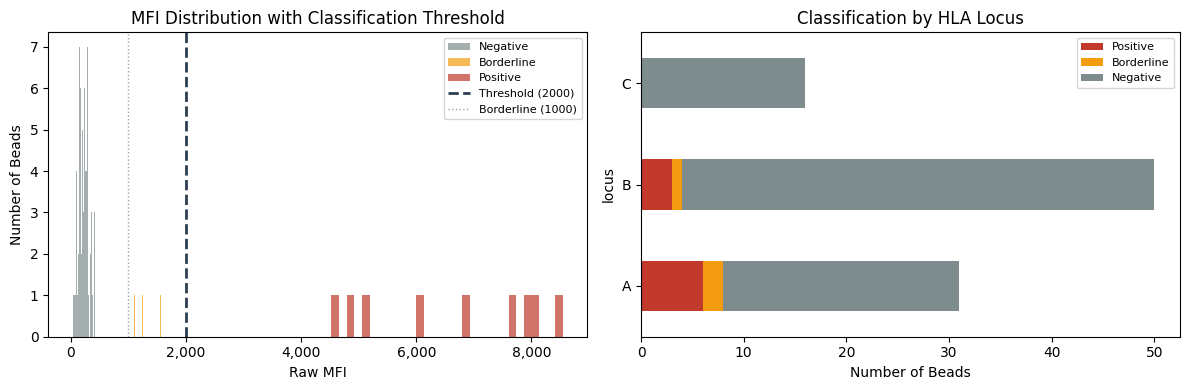

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: MFI histogram with threshold
ax = axes[0]
colors = {"Positive": "#c0392b", "Borderline": "#f39c12", "Negative": "#7f8c8d"}
for cls in ["Negative", "Borderline", "Positive"]:
    subset = df[df["classification"] == cls]
    ax.hist(subset["raw_mfi"], bins=30, alpha=0.7, label=cls, color=colors[cls])
ax.axvline(x=THRESHOLD, color="#2c3e50", linestyle="--", linewidth=2, label=f"Threshold ({THRESHOLD})")
ax.axvline(x=THRESHOLD * 0.5, color="#95a5a6", linestyle=":", linewidth=1, label=f"Borderline ({int(THRESHOLD*0.5)})")
ax.set_xlabel("Raw MFI")
ax.set_ylabel("Number of Beads")
ax.set_title("MFI Distribution with Classification Threshold")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Right: Summary by locus
ax2 = axes[1]
summary = df.groupby("locus")["classification"].value_counts().unstack(fill_value=0)
summary = summary.reindex(columns=["Positive", "Borderline", "Negative"], fill_value=0)
summary.plot(kind="barh", stacked=True, ax=ax2, color=[colors["Positive"], colors["Borderline"], colors["Negative"]])
ax2.set_xlabel("Number of Beads")
ax2.set_title("Classification by HLA Locus")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

---

## Part 3: Simple Virtual Crossmatch

A virtual crossmatch (VXM) predicts whether a patient's antibodies will react against a specific donor's HLA antigens. This is a critical pre-transplant compatibility assessment.

The basic logic:
1. Identify the patient's **positive antibodies** (from Part 2)
2. Compare against the **donor's HLA typing**
3. Any match = **donor-specific antibody (DSA)** = predicted positive crossmatch

Real-world VXM involves cross-reactive group analysis, epitope matching, and clinical context. This demo uses simple exact matching to illustrate how HAML enables the workflow.

In [24]:
from scripts.simple_vxm import read_donor_typing, identify_dsa, predict_vxm

# Load donor HLA typing
donor_path = REPO_ROOT / "data" / "sample_donor_typing.txt"
donor_alleles = read_donor_typing(donor_path)

print("Donor HLA Typing:")
for allele in sorted(donor_alleles):
    print(f"  {allele}")
print(f"\nTotal: {len(donor_alleles)} alleles")

Donor HLA Typing:
  A*02:01
  A*30:01
  B*07:02
  B*44:02
  C*05:01
  C*07:02
  DPA1*01:03
  DPB1*04:01
  DQA1*03:01
  DQB1*03:02
  DRB1*04:01
  DRB1*15:01
  DRB4*01:01
  DRB5*01:01

Total: 14 alleles


In [25]:
# Identify donor-specific antibodies and predict VXM
dsa_list = identify_dsa(all_beads, donor_alleles, threshold=THRESHOLD)
prediction = predict_vxm(dsa_list)

print(f"MFI Threshold: {THRESHOLD}")
print(f"{'=' * 55}\n")

if dsa_list:
    print(f"Donor-Specific Antibodies ({len(dsa_list)} found):\n")
    dsa_df = pd.DataFrame(dsa_list)
    dsa_df = dsa_df.sort_values("raw_mfi", ascending=False)
    print(dsa_df[["specificity", "locus", "raw_mfi", "match_type"]].to_string(index=False))
else:
    print("No donor-specific antibodies detected.")

print(f"\n{'=' * 55}")
print(f"Virtual Crossmatch Prediction: {prediction}")
print(f"{'=' * 55}")

MFI Threshold: 2000

Donor-Specific Antibodies (3 found):

specificity locus  raw_mfi match_type
    A*02:01     A   8542.0      exact
    B*44:02     B   4890.0      exact
    B*07:02     B   4521.0      exact

Virtual Crossmatch Prediction: Positive (Incompatible)


### Adding Class II Data

A complete VXM requires both Class I (HLA-A, B, C) and Class II (HLA-DR, DQ, DP) antibody data. Let's convert the Class II CSV and check for additional DSA. Class II heterodimer beads (DQ, DP) require chain-level matching: if either chain of the bead matches a donor allele, the bead is a DSA candidate.

In [26]:
# Convert and analyze Class II data
csv_path_c2 = REPO_ROOT / "data" / "sample_sab_class2.csv"
beads_c2 = read_fusion_csv(csv_path_c2)
root_c2 = build_haml(beads_c2, reporting_center="HAML Demo Laboratory",
                      hla_class="II", catalog="LS2A01")

# Save, parse, and find DSA
haml_path_c2 = output_dir / "demo_class2.haml.xml"
with open(haml_path_c2, "w") as f:
    f.write(etree.tostring(root_c2, pretty_print=True, xml_declaration=True, encoding="UTF-8").decode())

all_beads_c2 = parse_haml_beads(haml_path_c2)
dsa_c2 = identify_dsa(all_beads_c2, donor_alleles, threshold=THRESHOLD)

print(f"Class II: {len([b for b in all_beads_c2 if b['bead_type'] == 'target'])} target beads\n")

if dsa_c2:
    print(f"Class II DSA ({len(dsa_c2)} found):")
    for dsa in sorted(dsa_c2, key=lambda d: d["raw_mfi"], reverse=True):
        print(f"  {dsa['specificity']:<35} MFI: {dsa['raw_mfi']:>8.0f}  ({dsa['match_type']})")

# Combined VXM
all_dsa = dsa_list + dsa_c2
print(f"\n{'=' * 55}")
print(f"Combined VXM (Class I + II): {len(all_dsa)} total DSA")
print(f"Prediction: {predict_vxm(all_dsa)}")
print(f"{'=' * 55}")

Class II: 94 target beads

Class II DSA (2 found):
  DQA1*03:01~DQB1*03:02               MFI:     4567  (heterodimer-chain)
  DRB1*04:01                          MFI:     3456  (exact)

Combined VXM (Class I + II): 5 total DSA
Prediction: Positive (Incompatible)


---

## Discussion

### HAML as an Interoperability Standard

This notebook demonstrated the core value of HAML: **a single workflow that works regardless of which laboratory produced the data**. The same analyzer and VXM scripts would work on HAML files generated from Werfen MatchIt exports, institutional LIS data, or any other source, because the HAML schema standardizes the representation.

Without HAML, every analysis tool must implement parsers for each vendor's proprietary CSV format. With HAML, laboratories convert once (CSV to HAML), and all downstream tools consume the same format.

### What This Demo Does NOT Cover

This demo uses intentionally simplified logic to illustrate the HAML format. Clinical antibody interpretation involves:

- **Locus-specific thresholds** (HLA-C and DP have lower expression, requiring higher MFI cutoffs)
- **Cross-reactive group (CREG) analysis** to identify shared epitope patterns
- **Artifact detection** (prozone, complement interference, denatured antigens)
- **Historical antibody data** to assess temporal persistence and anamnestic risk
- **Platform concordance** when multiple vendor systems test the same sample
- **Eplet-level analysis** for molecular specificity resolution

These capabilities require domain-specific algorithms beyond simple threshold classification. The [IHIW Clinical Histocompatibility Laboratory Informatics project](https://www.ihiw.org/) is working to standardize these analyses alongside the HAML format.

### Next Steps

- **HAML 1.0 finalization:** The schema used here (version 0.6.1 draft) includes new support for cell-based assays (flow crossmatch, CDC) alongside solid-phase bead data. The version string will update to 1.0 upon publication.
- **Adjusted MFI and interpretations:** HAML supports multiple `bead-adjusted-data` entries per bead (background-corrected MFI, MFI ratios) and multiple `bead-interpretation` entries (software classification, expert override). These elements enable laboratories to share not just raw data but their analytical reasoning.
- **IHIW Converters:** Production-grade converters for IHIW database integration are maintained at [github.com/IHIW/Converters](https://github.com/IHIW/Converters).

---

*Demo scripts for the HAML 1.0 specification manuscript.*
*Vanessa Menard, Loren Gragert, Eric Spierings, Ben Matern*